In [1]:
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent

FEATURES = ROOT / "data" / "correctness_dataset" / "features" 

# Load specific family and split
family = "dd_xgb_wl_delta"
seed = 13
split = "train.npz"
path = FEATURES / family / f"seed_{seed}" / split

feature_file = np.load(path, allow_pickle=True)


In [3]:
X = feature_file["X"]
correctness_scores = feature_file["correctness_scores"]
feature_names = [str(name) for name in feature_file["feature_names"]]

df = pd.DataFrame(X, columns=feature_names)
df["correctness_score"] = correctness_scores

df.head()

,residual_l2_mean,residual_l2_std,residual_l2_min,residual_l2_max,residual_l2_final,residual_l1_mean_mean,residual_l1_mean_std,residual_l1_mean_min,residual_l1_mean_max,residual_l1_mean_final,...,log_plan_len,plan_to_budget_ratio,initial_goal_l2,final_goal_l2,final_minus_initial_goal_l2,hidden_h_final_norm,hidden_c_final_norm,hidden_h_abs_mean,hidden_c_abs_mean,correctness_score
0,0.938456,0.091166,0.831134,1.098572,0.939157,0.028814,0.003084,0.024657,0.033173,0.029370,...,1.945910,0.06,11.789826,3.872983,-7.916843,0.0,0.0,0.0,0.0,1.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00,11.789826,11.789826,0.000000,0.0,0.0,0.0,0.0,0.000000
2,2.714506,1.361658,1.009160,3.998766,3.998766,0.078327,0.037780,0.032176,0.118357,0.118357,...,1.791759,0.05,11.789826,6.480741,-5.309086,0.0,0.0,0.0,0.0,0.366667
3,1.346994,0.918368,0.831134,3.390383,0.875895,0.038675,0.022511,0.024657,0.088539,0.026169,...,1.945910,0.06,11.789826,5.000000,-6.789826,0.0,0.0,0.0,0.0,0.666667
4,1.766075,1.151819,0.831134,3.390383,3.390383,0.049070,0.028054,0.024657,0.088539,0.088539,...,1.945910,0.06,11.789826,6.244998,-5.544828,0.0,0.0,0.0,0.0,0.666667


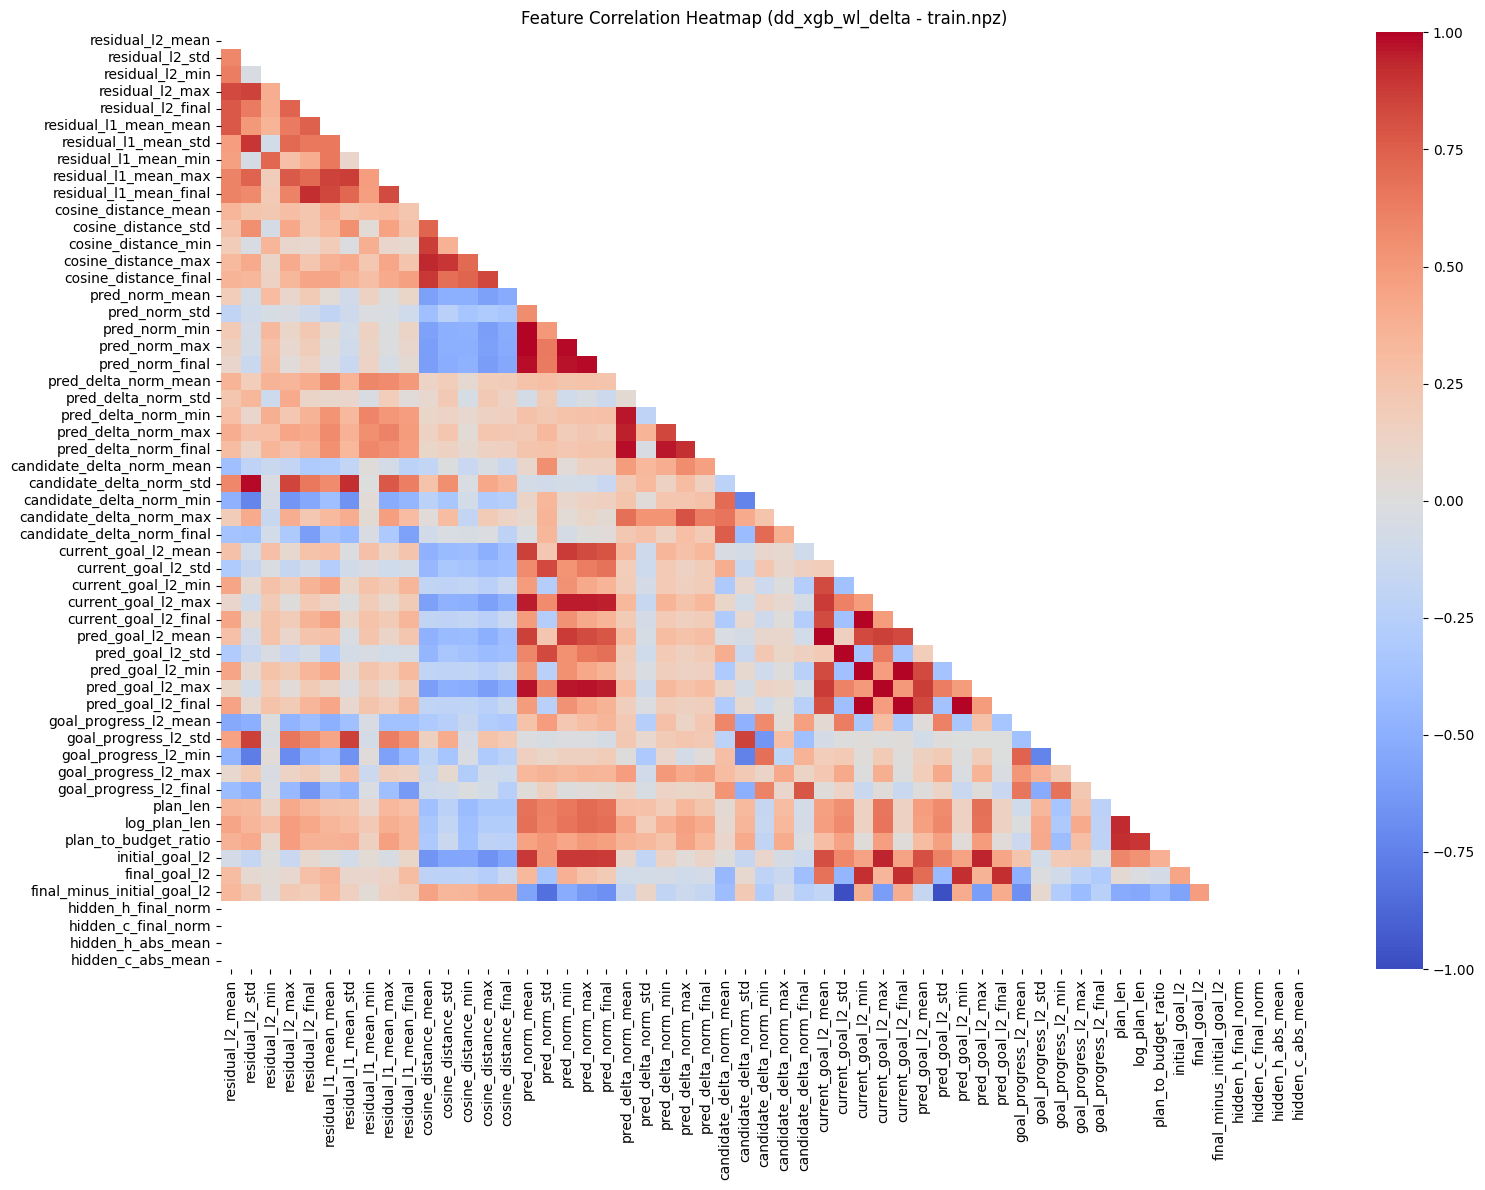

In [4]:
plt.figure(figsize=(16, 12))
plot_corr_matrix = df.drop("correctness_score", axis=1).corr()
mask = np.triu(np.ones_like(plot_corr_matrix, dtype=bool))

sns.heatmap(
    plot_corr_matrix, 
    mask=mask, 
    cmap="coolwarm", 
    center=0, 
    vmin=-1, vmax=1,
    xticklabels=True,
    yticklabels=True
)
plt.title(f"Feature Correlation Heatmap ({family} - {split})")
plt.tight_layout()

plt.show()

In [5]:
corr = df.corr(numeric_only=True)
target_corr = corr["correctness_score"].drop("correctness_score")

In [6]:
print("\nTop 15 Most Positively Correlated to Correctness Score:")
for feature, corr_value in target_corr.sort_values(ascending=False).head(55).items():
    print(f"* {feature:<35} {corr_value:.6f}")


Top 15 Most Positively Correlated to Correctness Score:
* goal_progress_l2_mean               0.766951
* candidate_delta_norm_mean           0.689773
* current_goal_l2_std                 0.606417
* pred_norm_std                       0.595913
* pred_goal_l2_std                    0.585665
* candidate_delta_norm_final          0.550362
* candidate_delta_norm_min            0.521169
* goal_progress_l2_final              0.453847
* goal_progress_l2_max                0.399986
* goal_progress_l2_min                0.390075
* pred_norm_final                     0.233698
* candidate_delta_norm_max            0.224431
* pred_delta_norm_mean                0.196694
* pred_delta_norm_max                 0.192278
* pred_delta_norm_min                 0.188495
* pred_norm_max                       0.188349
* pred_delta_norm_final               0.184975
* pred_norm_mean                      0.130879
* log_plan_len                        0.128604
* current_goal_l2_max                 0.108545
* p

In [7]:
for feature, corr_value in target_corr.sort_values(ascending=True).head(3).items():
    print(f"* {feature:<35} {corr_value:.6f}")

* final_goal_l2                       -0.668723
* final_minus_initial_goal_l2         -0.635553
* current_goal_l2_final               -0.540320


In [8]:
print("\nTop 10 Most Negatively Correlated to Correctness Score:")
for feature, corr_value in target_corr.sort_values(ascending=True).head(15).items():
    print(f"* {feature:<35} {corr_value:.6f}")


Top 10 Most Negatively Correlated to Correctness Score:
* final_goal_l2                       -0.668723
* final_minus_initial_goal_l2         -0.635553
* current_goal_l2_final               -0.540320
* current_goal_l2_min                 -0.539459
* pred_goal_l2_final                  -0.534222
* pred_goal_l2_min                    -0.533291
* residual_l1_mean_mean               -0.506213
* residual_l2_mean                    -0.428884
* residual_l1_mean_final              -0.392528
* residual_l2_final                   -0.358926
* residual_l1_mean_max                -0.316166
* residual_l1_mean_std                -0.315657
* candidate_delta_norm_std            -0.312488
* residual_l2_std                     -0.292623
* residual_l2_max                     -0.268420


In [ ]:
feature_corr_matrix = df.drop(columns=["correctness_score"]).corr(numeric_only=True)

upper_triangle = feature_corr_matrix.where(
    np.triu(np.ones(feature_corr_matrix.shape), k=1).astype(bool)
)

positive_corr_pairs = [
    (feat1, feat2, corr_val)
    for feat1 in upper_triangle.index
    for feat2 in upper_triangle.columns
    if pd.notna(corr_val := upper_triangle.loc[feat1, feat2])
    and corr_val > 0.95
]

negative_corr_pairs = [
    (feat1, feat2, corr_val)
    for feat1 in upper_triangle.index
    for feat2 in upper_triangle.columns
    if pd.notna(corr_val := upper_triangle.loc[feat1, feat2])
    and corr_val < -0.95
]

positive_corr_pairs.sort(key=lambda x: x[2], reverse=True)
negative_corr_pairs.sort(key=lambda x: x[2])

print("\nHighly Positively Correlated Feature Pairs (r > 0.95):")
for feat1, feat2, corr_val in positive_corr_pairs[:50]:
    print(f"* {corr_val:.3f} | {feat1} <--> {feat2}")



Highly Positively Correlated Feature Pairs (r > 0.95):
* 1.000 | current_goal_l2_min <--> current_goal_l2_final
* 0.999 | pred_goal_l2_min <--> pred_goal_l2_final
* 0.998 | current_goal_l2_std <--> pred_goal_l2_std
* 0.997 | pred_norm_mean <--> pred_norm_min
* 0.997 | current_goal_l2_max <--> pred_goal_l2_max
* 0.996 | current_goal_l2_final <--> pred_goal_l2_min
* 0.996 | current_goal_l2_min <--> pred_goal_l2_min
* 0.996 | current_goal_l2_mean <--> pred_goal_l2_mean
* 0.996 | current_goal_l2_final <--> pred_goal_l2_final
* 0.995 | current_goal_l2_min <--> pred_goal_l2_final
* 0.994 | pred_norm_mean <--> pred_norm_max
* 0.989 | pred_norm_max <--> pred_norm_final
* 0.986 | residual_l2_std <--> candidate_delta_norm_std
* 0.985 | pred_norm_min <--> pred_norm_max
* 0.983 | pred_norm_mean <--> pred_norm_final
* 0.979 | pred_delta_norm_mean <--> pred_delta_norm_final
* 0.973 | pred_norm_min <--> pred_norm_final
* 0.970 | pred_norm_max <--> pred_goal_l2_max
* 0.970 | pred_norm_mean <--> pred_

In [10]:
print("\nHighly Negatively Correlated Feature Pairs (r < -0.85):")
for feat1, feat2, corr_val in negative_corr_pairs[:50]:
   print(f"* {corr_val:.3f} | {feat1} <--> {feat2}")


Highly Negatively Correlated Feature Pairs (r < -0.85):
* -0.986 | current_goal_l2_std <--> final_minus_initial_goal_l2
* -0.982 | pred_goal_l2_std <--> final_minus_initial_goal_l2
